# Part 1 — Core concepts, mapped to the options problem

RL has about ten words you need. For each one you get:
**(1)** an everyday analogy, **(2)** what it means in our options-selection problem, and
**(3)** a mini exercise with code, expected output and a solution.

| Concept | One-line meaning | In our problem |
|---|---|---|
| Agent | the decision-maker | the strategy selector |
| Environment | everything the agent doesn't control | the market plus the rules of trading |
| State *s* | what the agent knows when it decides | VIX, IV rank, trend, term structure, open position… |
| Action *a* | a choice | one of 8: no trade or strategy 1–7 |
| Reward *r* | the immediate score | this week's P&L after costs (in \$1,000s) |
| Policy π | the decision rule, state → action | "if backwardation, buy the long straddle" |
| Return *G* | the sum of future rewards, discounted | total P&L over the coming year |
| Value V(s), Q(s,a) | *expected* return | "on average, a short straddle here earns \$90" |
| Discount γ | how much the future counts | γ = 0.9 → next week's \$ is worth 90¢ today |
| Exploration | trying things to learn | occasionally testing the long straddle |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import optrl
from optrl import metrics as M
M.set_style()
market = optrl.load_default_market()
table = optrl.weekly_pnl_table(market)
X = optrl.decision_features(market, table)
A = optrl.ACTION_NAMES
print(len(table), "weekly decision points; actions:", A)

1007 weekly decision points; actions: ['no_trade', 'short_straddle', 'iron_condor', 'bull_put_spread', 'bear_call_spread', 'long_straddle', 'bull_call_spread', 'bear_put_spread']


---
## 1.1 Agent and environment: the loop

**Analogy.** A thermostat (agent) and a room (environment). The thermostat reads the
temperature, turns the heater on or off, and the room responds. Repeat forever.

**In our problem.** Every Monday the agent reads the market, picks a strategy, and a week later
the market "responds" with a P&L. The environment includes the market **and** the trading
rules: sizing, costs, expiry.

```
       ┌──────────── state s_t (features) ────────────┐
       │                                              ▼
  ENVIRONMENT (market + rules)                    AGENT (policy π)
       ▲                                              │
       └──── action a_t (strategy) ─── reward r_t ◄───┘
```

**Formally:** at each step *t* the agent observes $s_t$, chooses $a_t$, and receives
$r_{t+1}$ and $s_{t+1}$. Here $t$ counts **weeks**. So $s_3$ is "the features on the 4th Monday".

Here's the loop in code. The `ContextualBandit` environment walks through the weeks in time
order and pays the P&L of whatever you choose.

In [2]:
env = optrl.ContextualBandit(X, table)
rng = np.random.default_rng(0)

state = env.reset()
total, done, steps = 0.0, False, 0
while not done:
    action = rng.integers(env.k)              # a *random* agent
    state, reward, done = env.step(action)
    total += reward; steps += 1
print(f"Random agent: {steps} weeks, total P&L ${total:,.0f}")

Random agent: 1007 weeks, total P&L $-70,364


A random agent loses a lot of money, because 3 of the 7 strategies lose on average. The rest of
the course is about doing better than that.

### 🛠 Exercise 1.1: your first hand-written agent
Write `rule_agent(state)` that encodes **your own** trading rule using the features
(`state` is a numpy array in the order `optrl.MarketData.FEATURES`). Suggestion: if
term structure > 1.0, buy the bear put spread (7). Otherwise sell the bull put spread (3).
Run it through the same loop.

*Expected:* this simple rule makes money (roughly +\$50k to +\$90k over 20 years). That's far
better than random. A good hand-written rule is your **first baseline**. RL must beat it to
earn its keep.

In [3]:
F = optrl.MarketData.FEATURES
print("feature order:", F)

def rule_agent(state):
    # TODO: return an action index 0..7
    return 0

def run(agent, env):
    s, total, done = env.reset(), 0.0, False
    while not done:
        s, r, done = env.step(agent(s)); total += r
    return total

print(f"Your rule: ${run(rule_agent, env):,.0f}")

feature order: ['vix', 'iv_rank', 'term_structure', 'ema_trend', 'rv_iv_spread', 'days_to_earnings', 'ret_5d']
Your rule: $0


**Solution**

In [4]:
TS = F.index("term_structure")

def rule_agent(state):
    return 7 if state[TS] > 1.0 else 3

print(f"Rule agent: ${run(rule_agent, env):,.0f}")

Rule agent: $80,315


---
## 1.2 State: what the agent knows

**Analogy.** A doctor's chart: temperature, blood pressure, history. It isn't the patient's
entire biology, just enough to decide what to do.

**In our problem.** The state is a vector of market features at the decision time, for example
`[vix=13.6, iv_rank=18, term_structure=0.89, ema_trend=-0.25, rv_iv_spread=-4.1, days_to_earnings=37, ret_5d=-0.8]`.
Later (Part 4 onward) the state also includes **your open position**.

**Two golden rules of state design**
1. **Only information available at decision time.** Using anything from the future is
   *look-ahead bias*. The agent looks brilliant in the backtest and fails live.
2. **Enough information to decide well.** If the best action depends on something the state
   doesn't include (like "is earnings this week?"), no algorithm can learn it.

### 🛠 Exercise 1.2: spot the leak
A colleague proposes adding `next_week_return` as a feature "because it's so predictive".
Show *how* predictive it is: compute the correlation between next week's return and the long
straddle's P&L. Then explain in one sentence why it's forbidden.

*Expected:* the correlation is huge (≈ 0.9). It's forbidden because on Monday
you don't know next week's return.

In [5]:
close = market.df["close"]
# TODO: next_week_return for each Monday in table.index (close 5 trading days later / close now - 1)
# then: np.corrcoef(abs(next_week_return), table["long_straddle"])

**Solution**

In [6]:
pos = market.df.index.get_indexer(table.index)
next_week_return = close.to_numpy()[pos + 5] / close.to_numpy()[pos] - 1
c = np.corrcoef(np.abs(next_week_return), table["long_straddle"])[0, 1]
print(f"corr(|next-week return|, long straddle P&L) = {c:.2f}  ← looks amazing, and it's pure look-ahead")

corr(|next-week return|, long straddle P&L) = 0.92  ← looks amazing, and it's pure look-ahead


The size of a move you haven't seen yet is exactly what a straddle bets on. An agent given this
feature would "learn" to buy straddles before big moves, which is impossible in real life.
**Always ask of every feature: would I have had this number at the Monday close?**

---
## 1.3 Action: what the agent can do

**Analogy.** A restaurant menu: a fixed, finite list of choices.

**In our problem.** 8 **discrete** actions: `0 = no_trade`, `1..7 = strategies`. The agent
chooses *which* strategy, not strikes or size. That keeps learning tractable. (Richer action
spaces, like choosing size too, come in Part 6's design discussion.)

**Why include "no trade"?** Because sometimes nothing has an edge after costs. Earnings weeks
are a good example: implied vol is expensive for buyers, and gap risk is dangerous for sellers.
Being able to sit out is a real skill.

### 🛠 Exercise 1.3: when is doing nothing the best action?
Earnings events cause gap moves, and implied vol is inflated going into them. Select the weeks
where earnings falls inside the option's life (`days_to_earnings` between 1 and 5) and compute
the average P&L of every action in those weeks.

*Expected:* about 80 earnings weeks, and **every one of the 7 strategies has a negative
average**. So `no_trade` (\$0) is the best action in expectation. A good agent should learn to
sit out earnings weeks.

In [7]:
# TODO

**Solution**

In [8]:
earn = X.days_to_earnings.between(1, 5)
print(f"{earn.sum()} earnings weeks. Average P&L per action:")
print(table[earn].mean().round(0).sort_values(ascending=False))

# ---
# ## 1.4 Reward: the score after each action
#
# **Analogy.** A video-game score that ticks up or down after each move. The agent will
# **maximise whatever you reward**, so reward the thing you truly want.
#
# **In our problem.** The default reward is this week's P&L after costs, scaled by \$1,000:
# a \$250 gain gives r = +0.25. Scaling keeps numbers near 1, which helps neural networks later.
#
# **The classic trap.** Reward raw P&L and the agent may love the short straddle: frequent small
# wins and rare disasters. If you care about risk, put risk in the reward. A simple choice is a
# **mean–variance penalty**:
#
# $$ r^{\text{risk}} = r - \lambda\, r^2 $$
#
# *In words:* subtract λ times the squared outcome, so big swings (in either direction) cost
# extra. *Worked example* with λ = 0.5: a +0.2 week gives 0.2 − 0.5·0.04 = **0.18**. A −2.0
# blowup week gives −2.0 − 0.5·4 = **−4.0**. The blowup is now twice as painful.
#
# ### 🛠 Exercise 1.4: the reward decides what "best" means
# Compute the average reward per week of **every** action for λ = 0, 0.25 and 0.5 (the P&L is in
# `table`). Which action is best under each λ?
#
# *Expected:* with λ = 0 the bull put spread is best (≈ +0.05 per week). As λ grows every strategy
# falls, the high-variance debit trades fastest. At λ = 0.5 **no strategy beats `no_trade`**, so
# an agent trained on that reward would learn to sit in cash. Too much risk aversion is also a
# bug. λ is a dial you'll tune in Part 9.

80 earnings weeks. Average P&L per action:
no_trade              0.0
short_straddle       -6.0
bear_call_spread     -9.0
bull_put_spread     -10.0
iron_condor         -38.0
long_straddle       -54.0
bear_put_spread     -74.0
bull_call_spread   -118.0
dtype: float64


In [9]:
def risk_reward(pnl, lam):
    # TODO: r = pnl/1000 ; return r - lam * r**2
    return None

**Solution**

In [10]:
def risk_reward(pnl, lam):
    r = np.asarray(pnl) / 1000
    return r - lam * r ** 2

rows = {lam: {a: risk_reward(table[a], lam).mean() for a in A} for lam in [0.0, 0.25, 0.5]}
R = pd.DataFrame(rows).T
print(R.round(3).to_string())
print("\nbest action per λ:", R.idxmax(axis=1).to_dict())

# ---
# ## 1.5 Policy: the decision rule
#
# **Analogy.** A recipe book: "if the guests are vegetarian → pasta; else → steak".
#
# **In our problem.** A policy π maps state → action. Two flavours:
# * **Deterministic**: π(s) = one action. *"VIX 13.6, contango → bull put spread."*
# * **Stochastic**: π(a|s) = a probability for each action. *"70% bull put, 20% short straddle,
#   10% no trade."* Randomness helps exploration, and some algorithms (PPO, Part 7b) learn
#   stochastic policies directly.
#
# A common way to turn **scores** into **probabilities** is the *softmax*:
#
# $$ \pi(a\mid s) = \frac{e^{h_a/\tau}}{\sum_b e^{h_b/\tau}} $$
#
# *In words:* exponentiate each action's score $h_a$ and divide by the total so they sum to 1.
# The temperature τ controls randomness. *Worked example:* scores h = [1, 2, 3] with τ = 1 give
# e¹, e², e³ ≈ 2.7, 7.4, 20.1 → probabilities 0.09, 0.24, **0.67**. With τ = 10 they're nearly
# uniform, 0.30, 0.33, 0.37.
#
# ### 🛠 Exercise 1.5
# Implement `softmax(h, tau)` and reproduce the two worked examples.

      no_trade  short_straddle  iron_condor  bull_put_spread  bear_call_spread  long_straddle  bull_call_spread  bear_put_spread
0.00       0.0           0.046        0.024            0.051             0.024         -0.190            -0.116           -0.277
0.25       0.0           0.023        0.002            0.025            -0.005         -0.342            -0.466           -0.607
0.50       0.0          -0.000       -0.020           -0.000            -0.033         -0.494            -0.815           -0.937

best action per λ: {0.0: 'bull_put_spread', 0.25: 'bull_put_spread', 0.5: 'no_trade'}


In [11]:
def softmax(h, tau=1.0):
    # TODO
    return None

**Solution**

In [12]:
def softmax(h, tau=1.0):
    z = np.asarray(h, float) / tau
    z = z - z.max()                      # numerical safety: doesn't change the result
    e = np.exp(z)
    return e / e.sum()

print(softmax([1, 2, 3], 1).round(2), softmax([1, 2, 3], 10).round(2))

[0.09 0.24 0.67] [0.3  0.33 0.37]


---
## 1.6 Return and discounting

**Analogy.** \$100 today is worth more than \$100 promised in a year. You discount the future,
both because it's uncertain and because you prefer money sooner.

**Formally.** The **return** from time *t* is the discounted sum of future rewards:

$$ G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \dots = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1} $$

*In words:* next week counts fully, the week after counts γ, then γ², and so on.

**Worked example.** Three weeks of P&L: +\$100, −\$50, +\$200, with γ = 0.9:
G = 100 + 0.9·(−50) + 0.81·200 = 100 − 45 + 162 = **\$217**.

**Rule of thumb.** γ sets an *effective horizon* of about 1/(1−γ) steps. γ = 0.9 → about 10
weeks. γ = 0.99 → about 100 weeks.

**Why it matters here.** If the agent only cares about this week (γ = 0), it will never accept
a small cost today (say closing a losing position) for a better position next week. Positions
that carry over (Part 4) need γ > 0.

### 🛠 Exercise 1.6
Write `discounted_return(rewards, gamma)` and check it on the worked example. Then compute the
discounted return of the **bull put spread** over its first 52 weeks in `table` for γ = 0, 0.9
and 0.99.

*Expected:* 217.0 for the worked example. For the 52 weeks, larger γ gives a number closer to
the plain sum (γ = 0 returns just the first week).

In [13]:
def discounted_return(rewards, gamma):
    # TODO
    return None

**Solution**

In [14]:
def discounted_return(rewards, gamma):
    G = 0.0
    for r in reversed(rewards):          # work backwards: G_t = r + γ G_{t+1}
        G = r + gamma * G
    return G

print(discounted_return([100, -50, 200], 0.9))
bp = table["bull_put_spread"].to_numpy()[:52]
for g in [0, 0.9, 0.99]:
    print(f"γ={g}: G = ${discounted_return(bp, g):,.0f}   (plain sum ${bp.sum():,.0f})")

217.0
γ=0: G = $180   (plain sum $3,353)
γ=0.9: G = $1,132   (plain sum $3,353)
γ=0.99: G = $2,690   (plain sum $3,353)


Notice the backwards loop: $G_t = r_{t+1} + \gamma G_{t+1}$. That one-line recursion is the
seed of the **Bellman equation** in Part 4.

---
## 1.7 Value functions: V(s) and Q(s, a)

**Analogy.** A chess player's gut feeling: "this position is worth about +2 pawns". That's not
a guarantee, it's an *expected* outcome.

**Formally.**
* $V^\pi(s) = \mathbb{E}[G_t \mid s_t = s]$, the expected return from state *s* if you follow π.
* $Q^\pi(s,a) = \mathbb{E}[G_t \mid s_t = s, a_t = a]$, the expected return if you take action *a*
  first and then follow π.

*In words:* **Q answers "how good is strategy a in situation s?"** If you knew Q exactly, the
best policy would be trivial: pick the action with the highest Q. Most of RL is estimating Q
(or V) from experience.

**Options example.** In a bandit (γ = 0) Q is just the average weekly P&L of each strategy in a
given situation. For s = "IV rank > 50 and term structure > 1 (stress)", Q(s, long_straddle)
is the average long-straddle P&L in such weeks.

### 🛠 Exercise 1.7: estimate Q by averaging (Monte Carlo)
Define two situations using the features:
* **stress**: `term_structure > 1.0`
* **calm**: `term_structure < 0.92` and `iv_rank < 30`

For each, estimate Q(s, a) for all 8 actions by averaging `table`. Which action is best in
each? Show it as a bar chart.

*Expected:* in **stress**, long vol or bearish debit spreads are best. In **calm**, bullish or
premium-selling strategies are best. The agent's future job is to learn this *automatically*.

In [15]:
# TODO

**Solution**

stress weeks: 145, calm weeks: 476
                  stress   calm
no_trade             0.0    0.0
short_straddle     -45.0   58.0
iron_condor        -42.0   35.0
bull_put_spread    -65.0  103.0
bear_call_spread    34.0  -22.0
long_straddle       44.0 -222.0
bull_call_spread  -307.0   98.0
bear_put_spread    137.0 -498.0

best: {'stress': 'bear_put_spread', 'calm': 'bull_put_spread'}


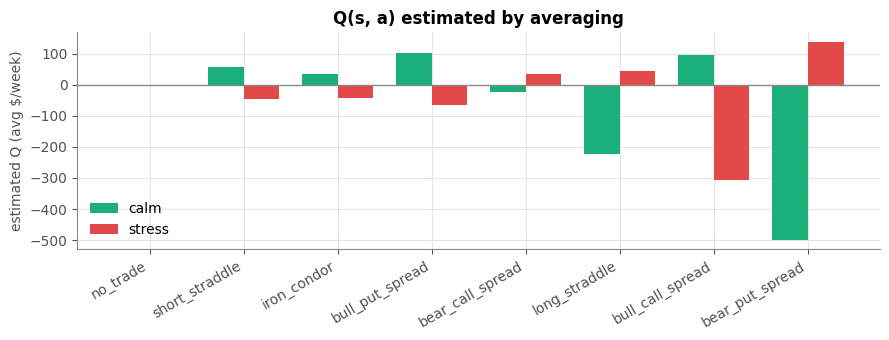

In [16]:
stress = X.term_structure > 1.0
calm = (X.term_structure < 0.92) & (X.iv_rank < 30)
Q = pd.DataFrame({"stress": table[stress].mean(), "calm": table[calm].mean()})
print(f"stress weeks: {stress.sum()}, calm weeks: {calm.sum()}")
print(Q.round(0)); print("\nbest:", Q.idxmax().to_dict())

fig, ax = plt.subplots(figsize=(9, 3.5))
xx = np.arange(len(A)); w = 0.38
ax.bar(xx - w/2, Q["calm"], w, label="calm", color=M.PALETTE[2])
ax.bar(xx + w/2, Q["stress"], w, label="stress", color=M.PALETTE[7])
ax.set_xticks(xx, A, rotation=30, ha="right"); ax.axhline(0, color="#8a8983", lw=1)
ax.set_ylabel("estimated Q (avg $/week)"); ax.set_title("Q(s, a) estimated by averaging"); ax.legend()
plt.tight_layout(); plt.show()

---
## 1.8 Exploration vs exploitation

**Analogy.** Your favourite restaurant is good. Do you go there again (**exploit**), or try the
new place that might be better, or worse (**explore**)? Never exploring means you might be
stuck with a mediocre favourite forever. Always exploring means you rarely enjoy the best one.

**In our problem.** Live, the agent only sees the P&L of the strategy it traded. If it tried
the iron condor first, got lucky, and never tried anything else, it would never learn that
something else is better. But exploring means **really trading** a strategy you suspect is
worse, which costs real money. In trading, exploration is expensive. That's why the
counterfactual backtest table is so valuable (Part 3).

### 🛠 Exercise 1.8: the greedy trap
Simulate a "pure greedy" learner. Try each strategy **once** (one random historical week),
then commit forever to whichever looked best. Repeat 1,000 times. How often does it commit to
the truly best strategy (highest long-run average)?

*Expected:* well under 50%. One sample per arm is dominated by noise. Part 2 fixes this.

In [17]:
# TODO

**Solution**

In [18]:
bandit = optrl.StrategyBandit(table.drop(columns="no_trade"), seed=0)
print("truly best:", bandit.names[bandit.best_arm], f"(avg ${bandit.true_means.max():.0f}/wk)")
picks = []
for _ in range(1000):
    first = [bandit.pull(a) for a in range(bandit.k)]
    picks.append(int(np.argmax(first)))
share = pd.Series(np.array(bandit.names)[picks]).value_counts(normalize=True)
print(share.round(3))
print(f"\nGreedy commits to the best strategy only {share.get(bandit.names[bandit.best_arm], 0):.0%} of the time")

truly best: bull_put_spread (avg $51/wk)


bull_call_spread    0.245
bear_put_spread     0.201
short_straddle      0.170
long_straddle       0.138
bull_put_spread     0.122
bear_call_spread    0.113
iron_condor         0.011
Name: proportion, dtype: float64

Greedy commits to the best strategy only 12% of the time


Why does greedy so often commit to the **bull call spread** or **bear put spread**, which both lose
on average? They are the most *volatile* arms. A single lucky draw from them is huge (+\$2,000), so they "look best"
after one sample even though they lose on average. **High-variance options strategies fool
naive learners.** Remember this. It comes back in every part.

## Recap
| Term | Our problem |
|---|---|
| state | market features (+ open position later) at Monday close |
| action | 0 = no trade, 1..7 = strategies |
| reward | P&L after costs ÷ \$1,000 (optionally risk-penalised) |
| policy | the rule mapping features → strategy |
| return, γ | discounted sum of future P&L. γ sets how far ahead the agent cares |
| Q(s,a) | expected P&L of strategy *a* in situation *s* |
| exploration | trying strategies to learn their value, at a real cost |

**Next → Part 2:** smarter ways to explore. ε-greedy, UCB and Thompson sampling.